<a href="https://colab.research.google.com/github/aysenuruyar-rgb/DSA210-Proj/blob/main/notebook/05_ML_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MAE: 2.9973319169801256
R^2: 0.9547374699412862


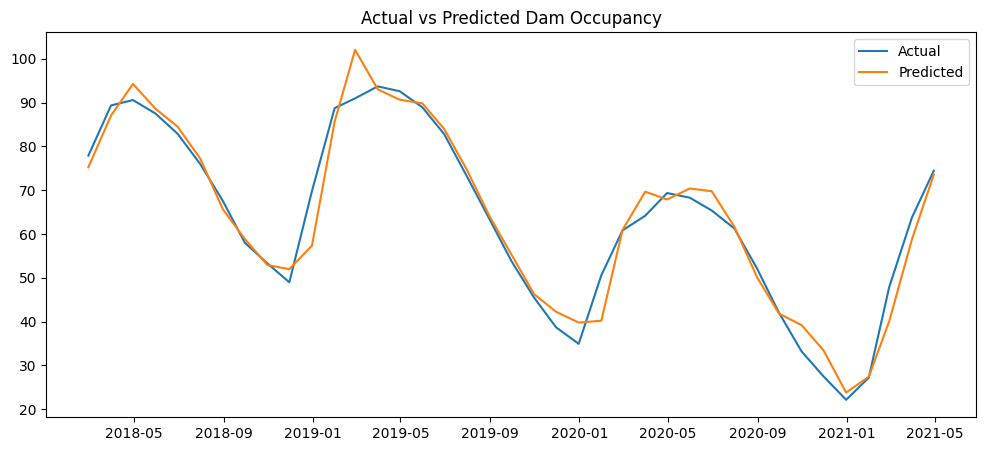

In [ ]:
import pandas as pd

df = pd.read_csv("featured_dataset.csv", index_col=0)
df.index = pd.to_datetime(df.index)

y = df["GENERAL_DAM_OCCUPANCY_RATE"]

X = df[[
    "dam_lag_1",
    "dam_lag_3",
    "rain_lag_1",
    "rain_lag_3",
    "snow_lag_1",
    "temp_lag_1",
    "rain_3m_avg",
    "temp_3m_avg",
    "rain_snow_total",
    "month_sin",
    "month_cos",
    "is_rainy"
]]

# split
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

# evaluation
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R^2:", r2)

# plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Dam Occupancy")
plt.show()

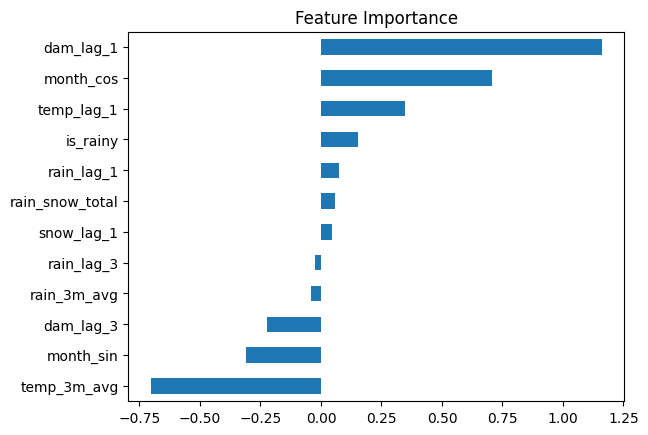

In [ ]:
import pandas as pd

importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("RF MSE:", mean_squared_error(y_test, y_pred_rf))
print("RF R²:", r2_score(y_test, y_pred_rf))

RF MSE: 25.182359366683183
RF R²: 0.9373764046840373


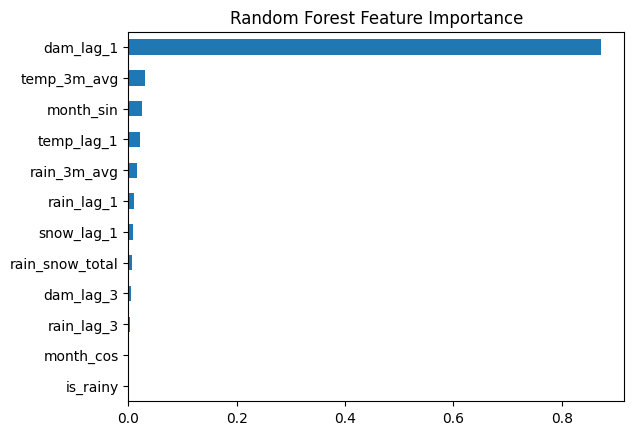

In [ ]:
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)

rf_importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()